In [ ]:
!pip install -q lightgbm imbalanced-learn kagglehub

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, f1_score
)
from imblearn.over_sampling import SMOTE
import lightgbm as lgb

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 100)
RANDOM_STATE = 42


In [ ]:
path = kagglehub.dataset_download("fedesoriano/company-bankruptcy-prediction")
print("Path to dataset files:", path)

import os
print(os.listdir(path))

csv_path = os.path.join(path, os.listdir(path)[0])
df = pd.read_csv(csv_path)

# Clean up column names
df.columns = [c.strip() for c in df.columns]
print(df.shape)
df.head()


100%|██████████| 4.63M/4.63M [00:00<00:00, 31.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/fedesoriano/company-bankruptcy-prediction/versions/2
['data.csv']
(6819, 96)


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,0.780985,1.256969e-04,0.0,0.458143,0.000725,0.0,0.147950,0.147950,0.147950,0.169141,0.311664,0.017560,0.095921,0.138736,0.022102,0.848195,0.688979,0.688979,0.217535,4.980000e+09,0.000327,0.263100,0.363725,0.002259,0.001208,0.629951,0.021266,0.207576,0.792424,0.005024,0.390284,0.006479,0.095885,0.137757,0.398036,0.086957,0.001814,0.003487,1.820926e-04,1.165007e-04,0.032903,0.034164,0.392913,0.037135,0.672775,0.166673,0.190643,0.004094,0.001997,1.473360e-04,0.147308,0.334015,0.276920,0.001036,0.676269,0.721275,0.339077,0.025592,0.903225,0.002022,0.064856,7.010000e+08,6.550000e+09,0.593831,4.580000e+08,0.671568,0.424206,0.676269,0.339077,0.126549,0.637555,0.458609,0.520382,0.312905,0.118250,0,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,0.781506,2.897851e-04,0.0,0.461867,0.000647,0.0,0.182251,0.182251,0.182251,0.208944,0.318137,0.021144,0.093722,0.169918,0.022080,0.848088,0.689693,0.689702,0.217620,6.110000e+09,0.000443,0.264516,0.376709,0.006016,0.004039,0.635172,0.012502,0.171176,0.828824,0.005059,0.376760,0.005835,0.093743,0.168962,0.397725,0.064468,0.001286,0.004917,9.360000e+09,7.190000e+08,0.025484,0.0068

## 3. Exploratory Data Analysis

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Bankrupt?                                                6819 non-null   int64  
 1   ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2   ROA(A) before interest and % after tax                   6819 non-null   float64
 3   ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4   Operating Gross Margin                                   6819 non-null   float64
 5   Realized Sales Gross Margin                              6819 non-null   float64
 6   Operating Profit Rate                                    6819 non-null   float64
 7   Pre-tax net Interest Rate                                6819 non-null   float64
 8   After-tax net Interest Rate 

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:", len(missing))
missing


Columns with missing values: 0


,0


In [ ]:
#duplicate rows and constant columns
print("Duplicate rows:", df.duplicated().sum())

constant_cols = [c for c in df.columns if df[c].nunique() <= 1]
print("Constant columns (no variance, safe to drop):", constant_cols)


Duplicate rows: 0
Constant columns (no variance, safe to drop): ['Net Income Flag']


Bankrupt?
0    6599
1     220
Name: count, dtype: int64
Bankrupt?
0    96.77
1     3.23
Name: proportion, dtype: float64


/tmp/ipykernel_1162/3304959795.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target, data=df, ax=ax[0], palette=["#4C72B0", "#C44E52"])
/tmp/ipykernel_1162/3304959795.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(["Not Bankrupt (0)", "Bankrupt (1)"])


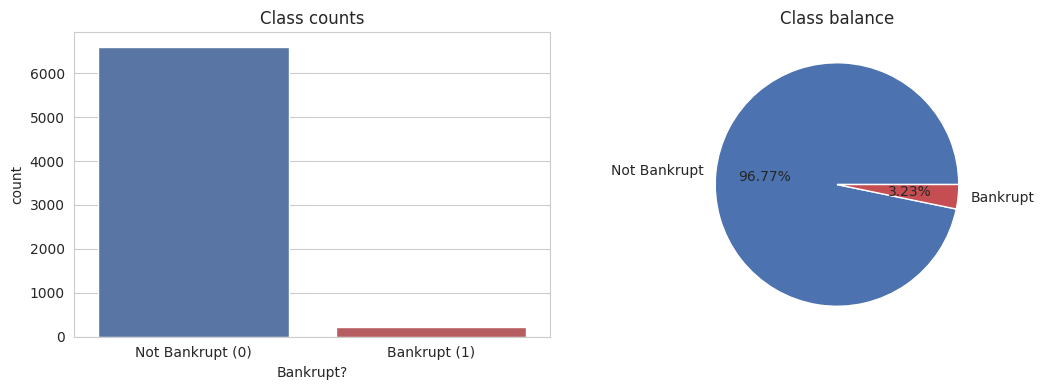

In [ ]:
# Target distribution
target = "Bankrupt?"
counts = df[target].value_counts()
pct = df[target].value_counts(normalize=True) * 100

print(counts)
print(pct.round(2))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x=target, data=df, ax=ax[0], palette=["#4C72B0", "#C44E52"])
ax[0].set_title("Class counts")
ax[0].set_xticklabels(["Not Bankrupt (0)", "Bankrupt (1)"])

ax[1].pie(counts, labels=["Not Bankrupt", "Bankrupt"], autopct="%1.2f%%",
          colors=["#4C72B0", "#C44E52"])
ax[1].set_title("Class balance")
plt.tight_layout()
plt.show()


In [ ]:
df.describe()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6.819000e+03,6.819000e+03,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6.819000e+03,6.819000e+03,6819.000000,6819.000000,6.819000e+03,6.819000e+03,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6.819000e+03,6.819000e+03,6.819000e+03,6.819000e+03,6819.000000,6.819000e+03,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6.819000e+03,6.819000e+03,6819.000000,6819.000000,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6.819000e+03,6.819000e+03,6819.000000,6.819000e+03,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,0.781381,1.995347e+09,1.950427e+09,0.467431,1.644801e+07,0.11

In [ ]:
#Correlation of every feature with the target variable
corr_with_target = (
    df.drop(columns=constant_cols, errors="ignore")
    .corr(numeric_only=True)[target]
    .drop(target)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

top_pos = corr_with_target.head(15)
top_neg = corr_with_target.tail(15)

print("Top 15 features most correlated with bankruptcy (by |r|):")
top_pos


Top 15 features most correlated with bankruptcy (by |r|):


,Bankrupt?
Net Income to Total Assets,-0.315457
ROA(A) before interest and % after tax,-0.282941
ROA(B) before interest and depreciation after tax,-0.273051
ROA(C) before interest and depreciation before interest,-0.260807
Net worth/Assets,-0.250161
Debt ratio %,0.250161
Persistent EPS in the Last Four Seasons,-0.219560
Retained Earnings to Total Assets,-0.217779
Net profit before tax/Paid-in capital,-0.207857
Per Share Net profit before tax (Yuan ¥),-0.201395


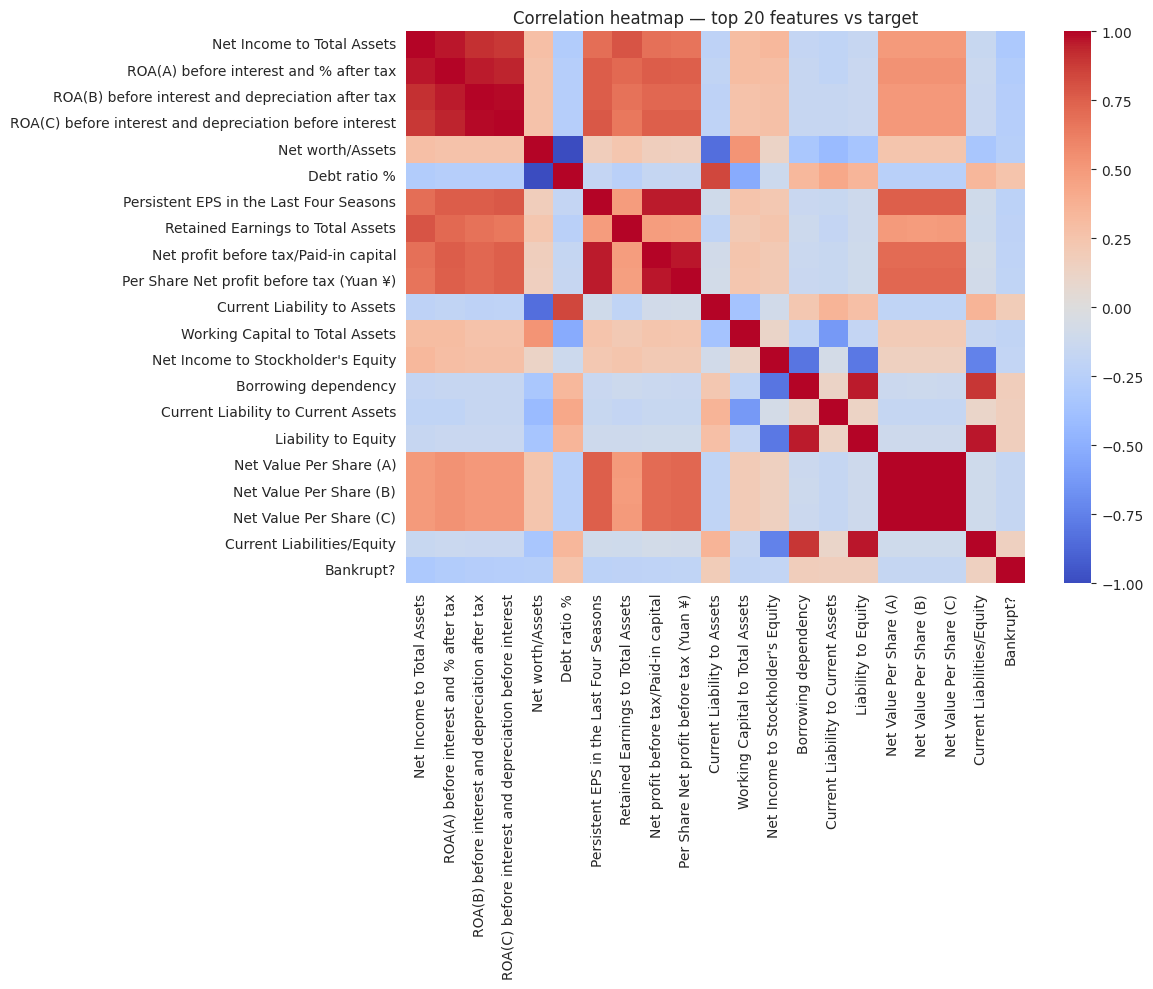

In [ ]:
#Correlation heatmap for the top 20 features
top_features = corr_with_target.abs().sort_values(ascending=False).head(20).index.tolist()

plt.figure(figsize=(12, 10))
sns.heatmap(df[top_features + [target]].corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation heatmap — top 20 features vs target")
plt.tight_layout()
plt.show()


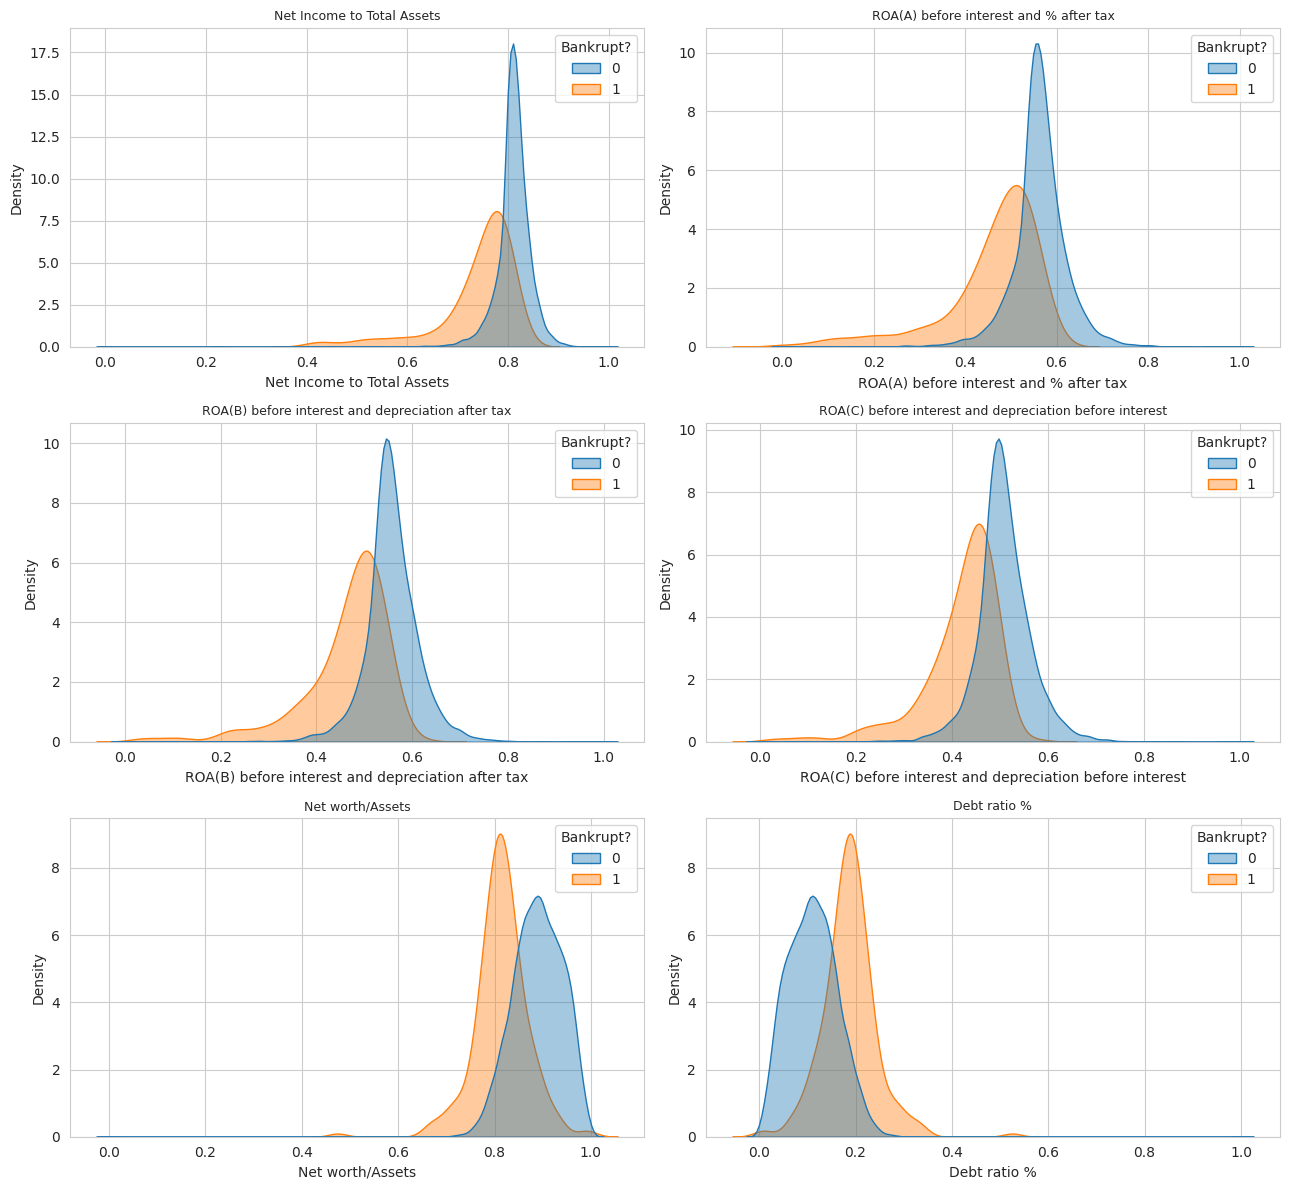

In [ ]:
#Distribution of top features split by class
fig, axes = plt.subplots(3, 2, figsize=(13, 12))
for ax, feat in zip(axes.flatten(), top_features[:6]):
    sns.kdeplot(data=df, x=feat, hue=target, common_norm=False, fill=True, alpha=0.4, ax=ax)
    ax.set_title(feat, fontsize=9)
plt.tight_layout()
plt.show()


/tmp/ipykernel_1162/124966743.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=feat, data=df, ax=ax, palette=["#4C72B0", "#C44E52"])
/tmp/ipykernel_1162/124966743.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=feat, data=df, ax=ax, palette=["#4C72B0", "#C44E52"])
/tmp/ipykernel_1162/124966743.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=feat, data=df, ax=ax, palette=["#4C72B0", "#C44E52"])


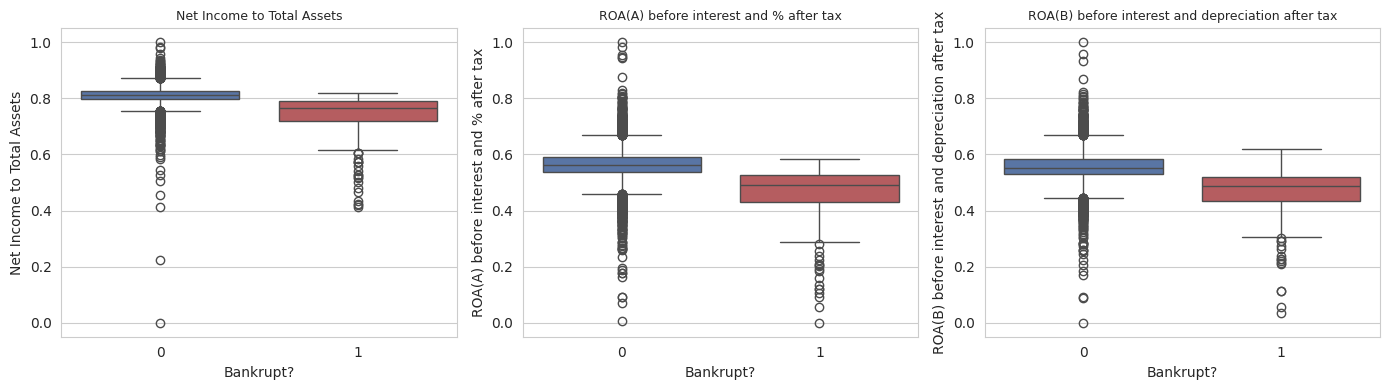

In [ ]:
#Outlier check
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feat in zip(axes, top_features[:3]):
    sns.boxplot(x=target, y=feat, data=df, ax=ax, palette=["#4C72B0", "#C44E52"])
    ax.set_title(feat, fontsize=9)
plt.tight_layout()
plt.show()


In [ ]:
#Handle outliers — cap instead of drop, so don't lose any bankrupt cases
def cap_outliers(data, cols, lower_pct=0.01, upper_pct=0.99):
    data_capped = data.copy()
    for col in cols:
        lower = data[col].quantile(lower_pct)
        upper = data[col].quantile(upper_pct)
        data_capped[col] = data[col].clip(lower=lower, upper=upper)
    return data_capped

outlier_cols = top_features[:10]
df_capped = cap_outliers(df, outlier_cols)

print("Rows before:", df.shape[0])
print("Rows after :", df_capped.shape[0])  # will be identical — that's the point
print("Bankrupt rate before:", df[target].mean().round(4))
print("Bankrupt rate after :", df_capped[target].mean().round(4))  # will also be identical

Rows before: 6819
Rows after : 6819
Bankrupt rate before: 0.0323
Bankrupt rate after : 0.0323


/tmp/ipykernel_1162/275130162.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=feat, data=df_capped, ax=ax, palette=["#4C72B0", "#C44E52"])
/tmp/ipykernel_1162/275130162.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=feat, data=df_capped, ax=ax, palette=["#4C72B0", "#C44E52"])
/tmp/ipykernel_1162/275130162.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=feat, data=df_capped, ax=ax, palette=["#4C72B0", "#C44E52"])


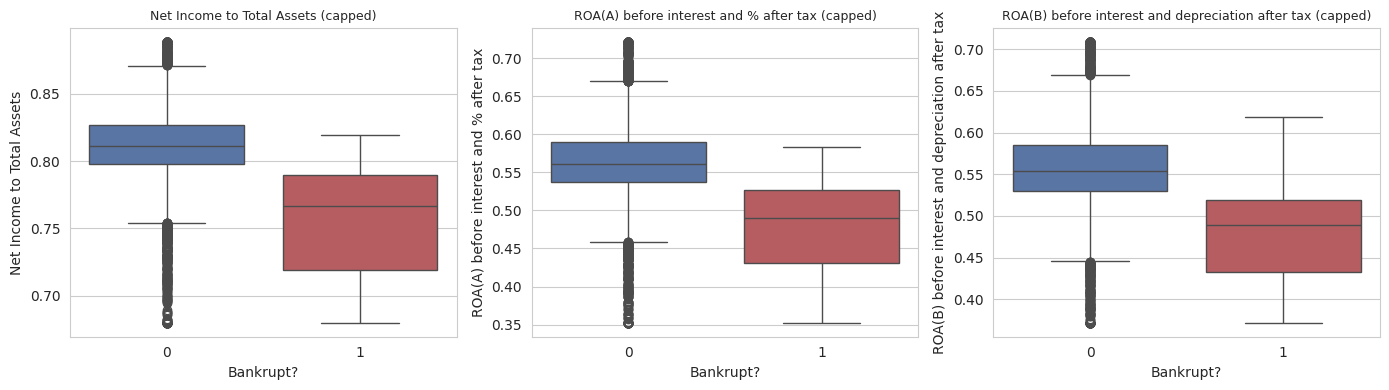

In [ ]:
# Boxplots AFTER capping
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feat in zip(axes, top_features[:3]):
    sns.boxplot(x=target, y=feat, data=df_capped, ax=ax, palette=["#4C72B0", "#C44E52"])
    ax.set_title(f"{feat} (capped)", fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
for feat in top_features[:3]:
    print(feat)
    print("  before:", round(df[feat].min(), 4), "-", round(df[feat].max(), 4))
    print("  after :", round(df_capped[feat].min(), 4), "-", round(df_capped[feat].max(), 4))
    print()

Net Income to Total Assets
  before: 0.0 - 1.0
  after : 0.6798 - 0.8883

ROA(A) before interest and % after tax
  before: 0.0 - 1.0
  after : 0.3525 - 0.7207

ROA(B) before interest and depreciation after tax
  before: 0.0 - 1.0
  after : 0.3718 - 0.7084



**EDA takeaways:**
- Dataset is clean: no missing values, but likely 1-2 constant columns (drop them) and possible extreme outliers/skew in ratio features.
- Severe class imbalance (~3% bankrupt) — accuracy will be misleading; we need to use `class_weight`, resampling (SMOTE), and rank/threshold metrics (ROC-AUC, PR-AUC, recall/F1 on the minority class).
- Profitability, leverage, and cash-flow ratios show the clearest separation between classes — these should dominate feature importance later.

## 4. Preprocessing

In [ ]:
#Drop constant columns, separate X / y — now using capped data
df_clean = df_capped.drop(columns=constant_cols, errors="ignore")
X = df_clean.drop(columns=[target])
y = df_clean[target]

print(X.shape, y.shape)

(6819, 94) (6819,)


In [ ]:
# Train/test split — stratified because of the imbalance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "Bankrupt rate:", y_train.mean().round(4))
print("Test :", X_test.shape, "Bankrupt rate:", y_test.mean().round(4))

Train: (5455, 94) Bankrupt rate: 0.0323
Test : (1364, 94) Bankrupt rate: 0.0323


In [ ]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Address class imbalance with SMOTE (train only)
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE :", pd.Series(y_train_sm).value_counts().to_dict())

Before SMOTE: {0: 5279, 1: 176}
After SMOTE : {0: 5279, 1: 5279}


## 5. Modeling

compare three models: a linear baseline (Logistic Regression), a bagged tree ensemble (Random Forest), and a boosted tree ensemble (LightGBM)

In [ ]:
#Helper: evaluate a fitted model consistently
def evaluate_model(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    roc_auc = roc_auc_score(y_te, y_proba)
    pr_auc = average_precision_score(y_te, y_proba)
    f1 = f1_score(y_te, y_pred)

    print(f"=== {name} ===")
    print(f"ROC-AUC: {roc_auc:.4f}   PR-AUC: {pr_auc:.4f}   F1 (class 1): {f1:.4f}")
    print(classification_report(y_te, y_pred, target_names=["Not Bankrupt", "Bankrupt"]))

    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(4, 3.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
    plt.title(f"{name} — Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return {"name": name, "roc_auc": roc_auc, "pr_auc": pr_auc, "f1": f1,
            "y_proba": y_proba}


=== Logistic Regression ===
ROC-AUC: 0.9113   PR-AUC: 0.3412   F1 (class 1): 0.2957
              precision    recall  f1-score   support

Not Bankrupt       0.99      0.88      0.94      1320
    Bankrupt       0.18      0.77      0.30        44

    accuracy                           0.88      1364
   macro avg       0.59      0.83      0.62      1364
weighted avg       0.97      0.88      0.91      1364



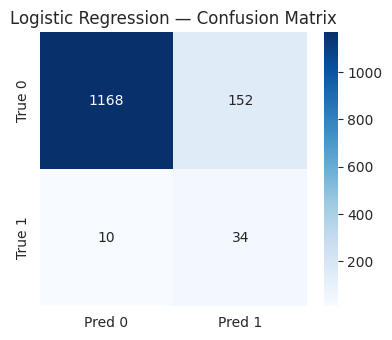

In [ ]:
#Logistic Regression (trained on SMOTE-balanced, scaled data)
log_reg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
log_reg.fit(X_train_sm, y_train_sm)

results_lr = evaluate_model("Logistic Regression", log_reg, X_test_scaled, y_test)


=== Random Forest ===
ROC-AUC: 0.9476   PR-AUC: 0.4980   F1 (class 1): 0.5045
              precision    recall  f1-score   support

Not Bankrupt       0.99      0.97      0.98      1320
    Bankrupt       0.42      0.64      0.50        44

    accuracy                           0.96      1364
   macro avg       0.70      0.80      0.74      1364
weighted avg       0.97      0.96      0.96      1364



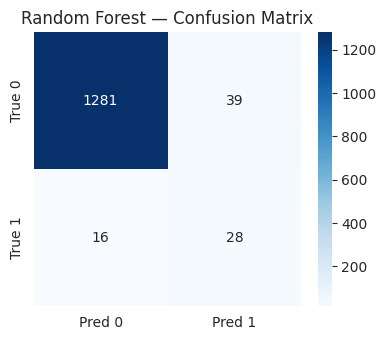

In [ ]:
#Random Forest (class_weight handles imbalance directly, using unscaled train
#but still fit on SMOTE-balanced data for consistency
rf = RandomForestClassifier(
    n_estimators=400, max_depth=None, min_samples_leaf=2,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train_sm, y_train_sm)

results_rf = evaluate_model("Random Forest", rf, X_test_scaled, y_test)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 176, number of negative: 5279
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006563 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 23713
[LightGBM] [Info] Number of data points in the train set: 5455, number of used features: 93
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032264 -> initscore=-3.401008
[LightGBM] [Info] Start training from score -3.401008
=== LightGBM ===
ROC-AUC: 0.9494   PR-AUC: 0.5208   F1 (class 1): 0.4872
              precision    recall  f1-score   support

Not Bankrupt       0.98      0.99      0.98      1320
    Bankrupt       0.56      0.43      0.49        44

    accuracy                           0.97      1364
   macro avg       0.77      0.71      0.74      1364
weighted avg       0.97      0.97      0.97      1364



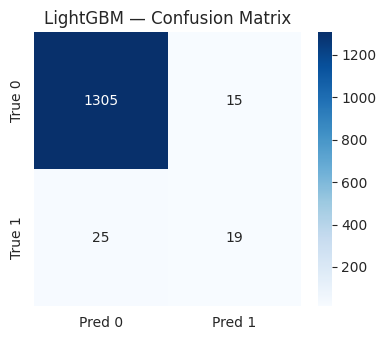

In [ ]:
#LightGBM. Use scale_pos_weight instead of SMOTE here so the model learns from the true data distribution
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

lgb_clf = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
)
lgb_clf.fit(X_train, y_train)  # raw (unscaled, non-SMOTE) — LightGBM handles this natively

results_lgb = evaluate_model("LightGBM", lgb_clf, X_test, y_test)


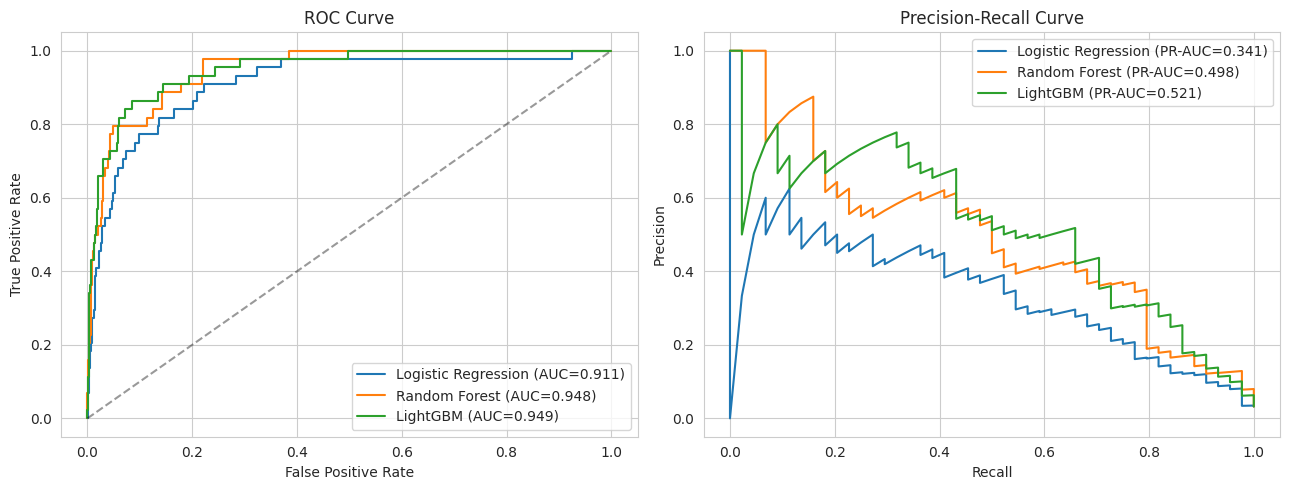

,Model,ROC-AUC,PR-AUC,F1
2,LightGBM,0.949380,0.520805,0.487179
1,Random Forest,0.947607,0.498009,0.504505
0,Logistic Regression,0.911312,0.341246,0.295652


In [ ]:
#Compare ROC and Precision-Recall curves across all three models
all_results = [results_lr, results_rf, results_lgb]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for res in all_results:
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    axes[0].plot(fpr, tpr, label=f"{res['name']} (AUC={res['roc_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

for res in all_results:
    prec, rec, _ = precision_recall_curve(y_test, res["y_proba"])
    axes[1].plot(rec, prec, label=f"{res['name']} (PR-AUC={res['pr_auc']:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

summary = pd.DataFrame([{"Model": r["name"], "ROC-AUC": r["roc_auc"],
                          "PR-AUC": r["pr_auc"], "F1": r["f1"]} for r in all_results])
summary.sort_values("PR-AUC", ascending=False)


### Model Comparison (ROC & Precision-Recall curves)

**ROC-AUC** (Logistic Regression 0.911, Random Forest 0.948, LightGBM 0.949):
All three models are quite strong at distinguishing bankrupt from healthy companies overall — anything above 0.9 is considered excellent. LightGBM and Random Forest are essentially tied at the top, both meaningfully ahead of Logistic Regression.

**PR-AUC** (Logistic Regression 0.341, Random Forest 0.498, LightGBM 0.521):
This is the more important number for this dataset, because only ~3% of companies are actually bankrupt. ROC-AUC can look great even when a model struggles with a rare class, because it's diluted by the huge majority of "easy" non-bankrupt cases. PR-AUC focuses specifically on how well the model handles the bankrupt cases — and here, the gap between models is much bigger:
- LightGBM leads (0.521), tightly followed by Random Forest (0.498)
- Logistic Regression falls well behind (0.341)

**Conclusion:** LightGBM is the best model for this problem, with Random Forest a close second. Logistic Regression, while still usable, is clearly the weakest at correctly ranking companies by bankruptcy risk when the class is this imbalanced. This is a typical result — tree-based ensemble models generally outperform linear models on tabular financial ratio data with rare-event targets.



## 6. Feature Importance (LightGBM)

/tmp/ipykernel_1162/3523789650.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.head(20).values, y=importances.head(20).index, palette="viridis")


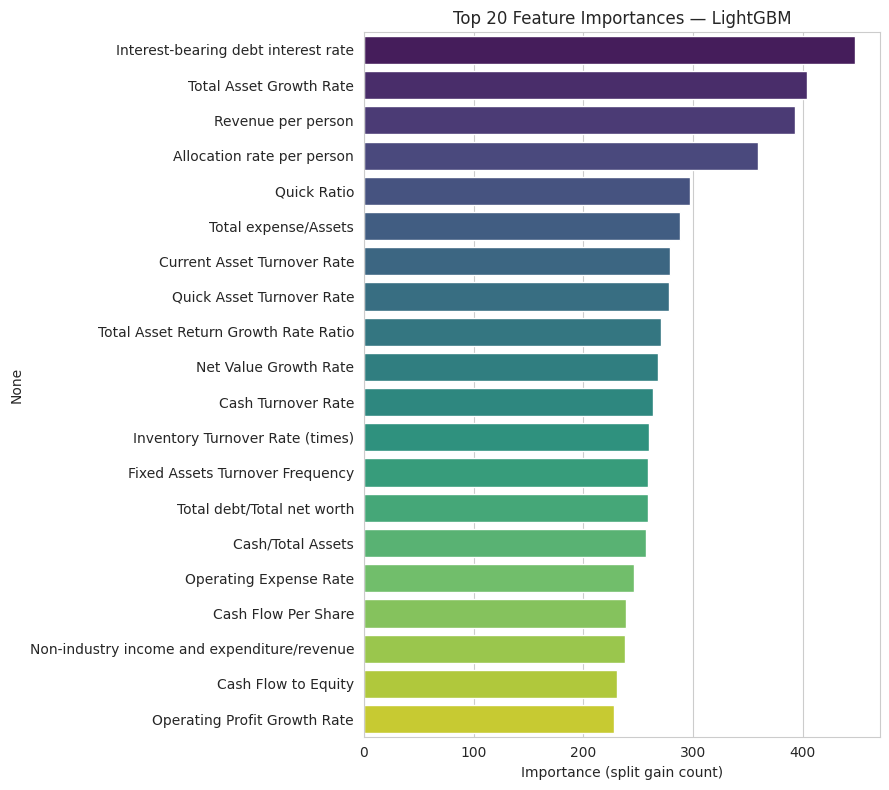

,0
Interest-bearing debt interest rate,448
Total Asset Growth Rate,404
Revenue per person,393
Allocation rate per person,359
Quick Ratio,297
Total expense/Assets,288
Current Asset Turnover Rate,279
Quick Asset Turnover Rate,278
Total Asset Return Growth Rate Ratio,271
Net Value Growth Rate,268


In [24]:
importances = pd.Series(lgb_clf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 8))
sns.barplot(x=importances.head(20).values, y=importances.head(20).index, palette="viridis")
plt.title("Top 20 Feature Importances — LightGBM")
plt.xlabel("Importance (split gain count)")
plt.tight_layout()
plt.show()

importances.head(20)


## 7. Prediction Export for Dashboard

In [25]:
#predictions from all three models on the test set
log_reg_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
rf_proba = rf.predict_proba(X_test_scaled)[:, 1]
lgb_proba = lgb_clf.predict_proba(X_test)[:, 1]

results_export = X_test.copy()
results_export["actual_bankrupt"] = y_test.values

results_export["logreg_proba"] = log_reg_proba
results_export["rf_proba"] = rf_proba
results_export["lgbm_proba"] = lgb_proba

#Predicted class at default 0.5 threshold (using LightGBM as the primary model)
results_export["lgbm_predicted"] = (lgb_proba >= 0.5).astype(int)


results_export["risk_bucket"] = pd.cut(
    lgb_proba,
    bins=[0, 0.2, 0.5, 0.8, 1.0],
    labels=["Low", "Medium", "High", "Very High"],
    include_lowest=True
)

print(results_export.shape)
results_export.head()

(1364, 100)


,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Equity to Liability,actual_bankrupt,logreg_proba,rf_proba,lgbm_proba,lgbm_predicted,risk_bucket
1244,0.503242,0.556149,0.552278,0.609399,0.609399,0.999043,0.797445,0.809349,0.303466,0.781609,1.792366e-04,0.000000e+00,0.464137,0.000677,0.305294,0.174624,0.174624,0.174624,0.221424,0.322416,0.035573,0.108867,0.178203,0.022085,0.848011,0.689259,0.689259,0.217577,6.940000e+09,0.000461,0.263721,0.382475,0.007731,0.005948,0.632256,0.010452,0.157995,0.842005,0.005013,0.377514,0.005366,0.108848,0.177226,0.404004,0.143928,0.000745,0.008497,0.000159,1.293611e-04,0.042258,0.012881,0.395468,0.013122,0.776891,0.348043,0.425024,0.046361,0.006166,0.002393,0.102555,0.345771,0.277450,0.004395,0.613886,0.734249,0.331976,0.009540,0.934622,0.002277,0.035324,1.143104e-04,9.710000e+09,0.593934,3.600000e+09,0.671569,0.571777,0.613886,0.331976,0.119148,0.637692,0.458428,0.590727,0.313521,0.037513,0,0.805667,0.000830,0.623746,0.609399,0.841004,0.282359,0.027273,0.566736,0.022839,0,0.198310,0.132708,0.000042,0,Low
6303,0.485984,0.547754,0.530649,0.598812,0.598812,0.999002,0.797424,0.809331,0.303516,0.781591,5.060000e+08,5.430000e+08,0.468455,0.000478,0.404899,0.197463,0.197463,0.197463,0.220384,0.331718,0.050622,0.104877,0.177902,0.022059,0.847999,0.689180,0.689180,0.217568,6.060000e+09,0.000455,0.263271,0.393242,0.005662,0.005094,0.631828,0.005165,0.106721,0.893279,0.019780,0.374069

In [26]:
#export feature importances as their own table
feature_importance_export = pd.DataFrame({
    "feature": X.columns,
    "importance": lgb_clf.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

feature_importance_export.head(20)

,feature,importance
0,Interest-bearing debt interest rate,448
1,Total Asset Growth Rate,404
2,Revenue per person,393
3,Allocation rate per person,359
4,Quick Ratio,297
5,Total expense/Assets,288
6,Current Asset Turnover Rate,279
7,Quick Asset Turnover Rate,278
8,Total Asset Return Growth Rate Ratio,271
9,Net Value Growth Rate,268


In [ ]:
#Save to CSV
results_export.to_csv("bankruptcy_predictions.csv", index=False)
feature_importance_export.to_csv("feature_importance.csv", index=False)

print("Saved: bankruptcy_predictions.csv and feature_importance.csv")

Saved: bankruptcy_predictions.csv and feature_importance.csv


In [ ]:
#download
from google.colab import files
files.download("bankruptcy_predictions.csv")
files.download("feature_importance.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
model_comparison = pd.DataFrame([
    {"model": "Logistic Regression", "roc_auc": results_lr["roc_auc"], "pr_auc": results_lr["pr_auc"], "f1": results_lr["f1"]},
    {"model": "Random Forest", "roc_auc": results_rf["roc_auc"], "pr_auc": results_rf["pr_auc"], "f1": results_rf["f1"]},
    {"model": "LightGBM", "roc_auc": results_lgb["roc_auc"], "pr_auc": results_lgb["pr_auc"], "f1": results_lgb["f1"]},
])

model_comparison.to_csv("model_comparison.csv", index=False)
print(model_comparison)

                 model   roc_auc    pr_auc        f1
0  Logistic Regression  0.911312  0.341246  0.295652
1        Random Forest  0.947607  0.498009  0.504505
2             LightGBM  0.949380  0.520805  0.487179


In [28]:
from google.colab import files
files.download("model_comparison.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
df["Interest-bearing debt interest rate"].quantile([0.25, 0.5, 0.75, 0.9, 0.99])

,Interest-bearing debt interest rate
0.25,2.030203e-04
0.50,3.210321e-04
0.75,5.325533e-04
0.90,7.852785e-04
0.99,7.582000e+08
